<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 22</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Transformations <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos: log a right-skewed variable straight, climb the ladder of powers, square-root count data to stabilize its variance, let Box-Cox pick the power for you, and see why the back-transformed mean is not the mean.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Log tames the tail | a right-skewed variable to near-symmetric |
| 2 | The ladder of powers | one variable, four rungs, four shapes |
| 3 | Square-root for counts | stabilize variance on Poisson data |
| 4 | Box-Cox picks the power | maximum-likelihood lambda + Q-Q check |
| 5 | The back-transform trap | exp(mean of logs) is the GEOMETRIC mean |

> A transformation is NONLINEAR, so it changes the shape (unlike standardizing in Chapter 12, which does not).

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(22)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · LOG TAMES THE TAIL</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🪜 Right-skew to near-symmetric</div>
<div style="color:#4a5578;margin-top:6px">The headline transform from Chapter 11, in close-up. A log pulls in a long right tail because it compresses large values far more than small ones. Watch the skewness collapse toward 0. The catch: log needs strictly positive data.</div>
</div>

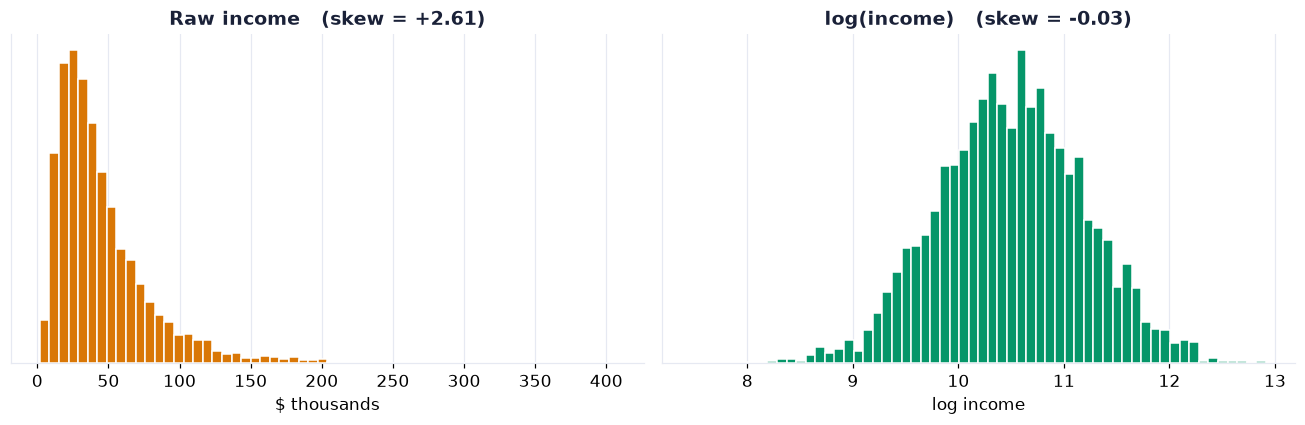

Skew fell from strongly positive to near 0. On the log scale, equal distances mean equal RATIOS (percent change).
Zeros or negatives? log breaks. Use log1p, a shift, or Yeo-Johnson (Demo 4).


In [2]:
income = rng.lognormal(mean=10.5, sigma=0.7, size=4000)   # right-skewed, all positive
logged = np.log(income)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(income/1000, bins=60, color=AMBER, edgecolor="white")
a1.set_title(f"Raw income   (skew = {stats.skew(income):+.2f})"); a1.set_xlabel("$ thousands"); a1.set_yticks([])
a2.hist(logged, bins=60, color=GREEN, edgecolor="white")
a2.set_title(f"log(income)   (skew = {stats.skew(logged):+.2f})"); a2.set_xlabel("log income"); a2.set_yticks([])
plt.tight_layout(); plt.show()
print("Skew fell from strongly positive to near 0. On the log scale, equal distances mean equal RATIOS (percent change).")
print("Zeros or negatives? log breaks. Use log1p, a shift, or Yeo-Johnson (Demo 4).")

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE LADDER OF POWERS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🪜 Tukey's organizing idea</div>
<div style="color:#4a5578;margin-top:6px">Every transform is a rung on one ladder. Going DOWN (sqrt, log, 1/x) pulls in a right skew; going UP (x squared) pulls in a left skew. Here is one right-skewed variable seen from four rungs, with its skewness on each.</div>
</div>

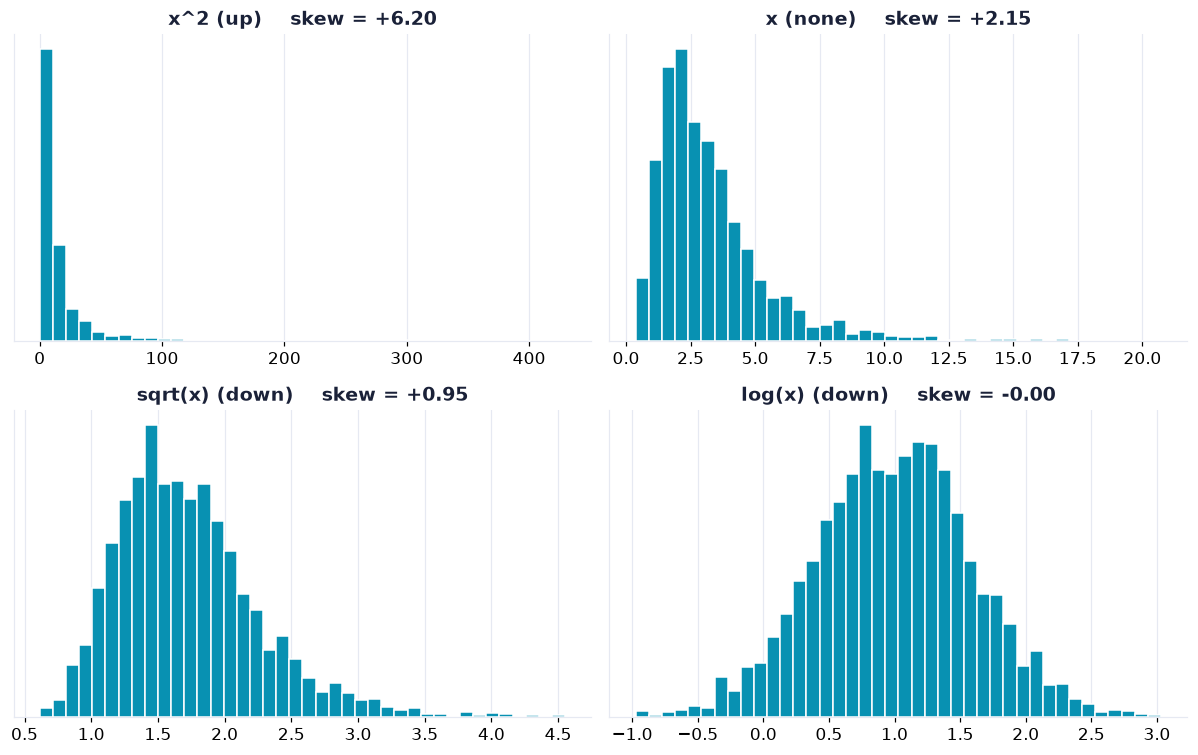

Up the ladder (x^2) makes the right skew WORSE; down the ladder (sqrt, then log) pulls it toward symmetry.


In [3]:
x = rng.lognormal(mean=1.0, sigma=0.6, size=3000)   # right-skewed, positive
rungs = [("x^2 (up)", x**2), ("x (none)", x), ("sqrt(x) (down)", np.sqrt(x)), ("log(x) (down)", np.log(x))]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, vals) in zip(axes.ravel(), rungs):
    ax.hist(vals, bins=40, color=CYAN, edgecolor="white")
    ax.set_title(f"{name}    skew = {stats.skew(vals):+.2f}"); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("Up the ladder (x^2) makes the right skew WORSE; down the ladder (sqrt, then log) pulls it toward symmetry.")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · SQUARE-ROOT FOR COUNTS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Stabilizing variance</div>
<div style="color:#4a5578;margin-top:6px">Count data (Poisson) has a built-in problem: the variance grows with the mean (variance is about equal to the mean). The square root is the classic variance-stabilizing transform, it flattens that dependence so groups become comparable.</div>
</div>

RAW counts:
  low  group: mean   4.0, variance    4.2
  high group: mean  80.0, variance   81.4   <- variance tracks the mean

After sqrt:
  low  group: variance 0.32
  high group: variance 0.25   <- now both near ~0.25, stabilized


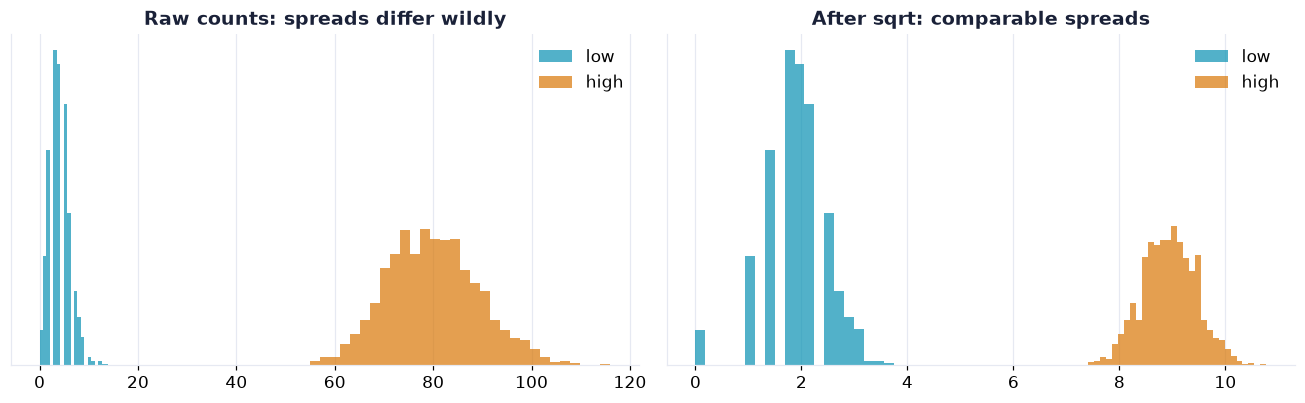

In [4]:
low  = rng.poisson(4,  2000)     # small counts
high = rng.poisson(80, 2000)     # large counts
print("RAW counts:")
print(f"  low  group: mean {low.mean():5.1f}, variance {low.var():6.1f}")
print(f"  high group: mean {high.mean():5.1f}, variance {high.var():6.1f}   <- variance tracks the mean")
print("\nAfter sqrt:")
print(f"  low  group: variance {np.sqrt(low).var():.2f}")
print(f"  high group: variance {np.sqrt(high).var():.2f}   <- now both near ~0.25, stabilized")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.hist(low, bins=20, alpha=0.7, color=CYAN, label="low"); a1.hist(high, bins=30, alpha=0.7, color=AMBER, label="high")
a1.set_title("Raw counts: spreads differ wildly"); a1.set_yticks([]); a1.legend()
a2.hist(np.sqrt(low), bins=20, alpha=0.7, color=CYAN, label="low"); a2.hist(np.sqrt(high), bins=30, alpha=0.7, color=AMBER, label="high")
a2.set_title("After sqrt: comparable spreads"); a2.set_yticks([]); a2.legend()
plt.tight_layout(); plt.show()

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · BOX-COX PICKS THE POWER</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 Maximum-likelihood lambda</div>
<div style="color:#4a5578;margin-top:6px">Box-Cox is a slider across the ladder: it finds the power lambda that best normalizes the data (lambda=1 none, 0.5 sqrt, 0 log, -1 reciprocal). scipy returns the optimal lambda. A Q-Q plot confirms the result is close to normal. Box-Cox needs positive data; Yeo-Johnson handles zero/negatives.</div>
</div>

Box-Cox chose lambda = -0.000  (near 0 -> essentially a log)
skew: raw +3.49  ->  Box-Cox -0.00


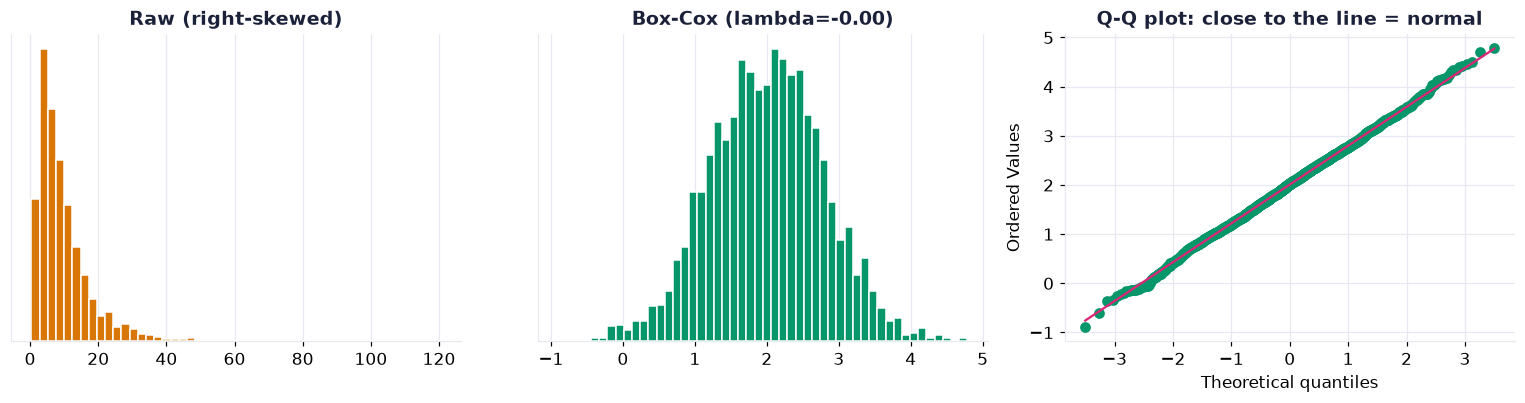

In ML, fit the transform (the lambda) on TRAIN only, then apply to test, same no-leakage rule as scaling.


In [5]:
x = rng.lognormal(mean=2.0, sigma=0.8, size=3000)
bc, lam = stats.boxcox(x)        # returns transformed data and the ML-optimal lambda
print(f"Box-Cox chose lambda = {lam:.3f}  (near 0 -> essentially a log)")
print(f"skew: raw {stats.skew(x):+.2f}  ->  Box-Cox {stats.skew(bc):+.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(x, bins=50, color=AMBER, edgecolor="white"); axes[0].set_title("Raw (right-skewed)"); axes[0].set_yticks([])
axes[1].hist(bc, bins=50, color=GREEN, edgecolor="white"); axes[1].set_title(f"Box-Cox (lambda={lam:.2f})"); axes[1].set_yticks([])
stats.probplot(bc, plot=axes[2]); axes[2].set_title("Q-Q plot: close to the line = normal")
axes[2].get_lines()[0].set_color(GREEN); axes[2].get_lines()[1].set_color(PINK)
plt.tight_layout(); plt.show()
print("In ML, fit the transform (the lambda) on TRAIN only, then apply to test, same no-leakage rule as scaling.")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · THE BACK-TRANSFORM TRAP</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">⚖️ exp(mean of logs) is NOT the mean</div>
<div style="color:#4a5578;margin-top:6px">After transforming you must back-transform to report in real units, but a concave function like log bends the average. exp(mean(log x)) lands on the GEOMETRIC mean, which sits below the arithmetic mean (Jensen's inequality). Report the median, or apply a bias correction.</div>
</div>

arithmetic mean      :     29.8
exp(mean of logs)    :     20.1   <- the GEOMETRIC mean, biased LOW
median               :     20.0   <- back-transforms cleanly (monotone preserves order)


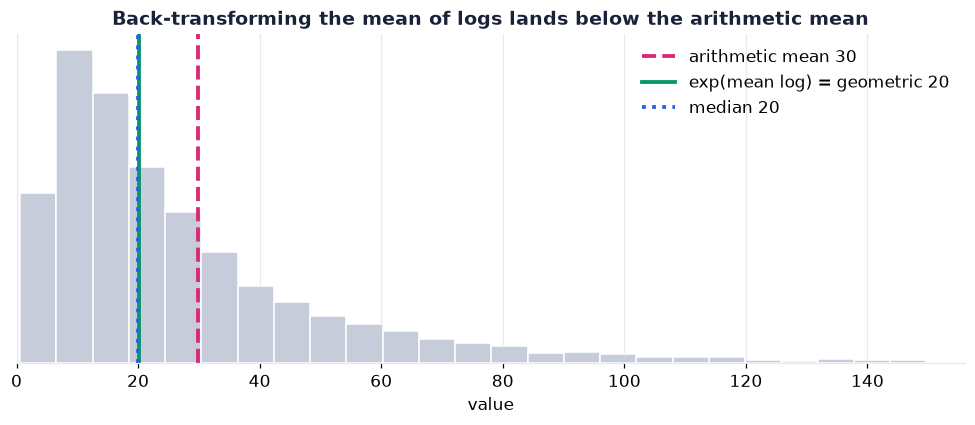

In [6]:
x = rng.lognormal(mean=3.0, sigma=0.9, size=5000)
arith = x.mean()
geo   = np.exp(np.log(x).mean())     # back-transformed mean of logs = geometric mean
med   = np.median(x)
print(f"arithmetic mean      : {arith:8.1f}")
print(f"exp(mean of logs)    : {geo:8.1f}   <- the GEOMETRIC mean, biased LOW")
print(f"median               : {med:8.1f}   <- back-transforms cleanly (monotone preserves order)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(x, bins=70, color="#c7ccda", edgecolor="white")
ax.axvline(arith, color=PINK,  lw=2.5, ls="--", label=f"arithmetic mean {arith:.0f}")
ax.axvline(geo,   color=GREEN, lw=2.5, ls="-",  label=f"exp(mean log) = geometric {geo:.0f}")
ax.axvline(med,   color=BLUE,  lw=2.5, ls=":",  label=f"median {med:.0f}")
ax.set_xlim(0, np.percentile(x, 99)); ax.set_yticks([]); ax.set_xlabel("value"); ax.legend()
ax.set_title("Back-transforming the mean of logs lands below the arithmetic mean")
plt.tight_layout(); plt.show()

## ⏱️ Real-World Example: Response Times
API response times are reliably right-skewed. We take 500 of them and **race four transforms**, raw, log, square-root, and Box-Cox, scoring each by how close it brings the skewness to zero. The log and Box-Cox transforms turn a lopsided column into a near-symmetric one; the square root only helps partway. The winning transform is the one you would feed a model.

raw                    skewness = +1.66
log                    skewness = +0.10
sqrt                   skewness = +0.84
Box-Cox (lam=-0.06)    skewness = +0.00

log and Box-Cox pull the skew to about 0; the square root only helps partway.


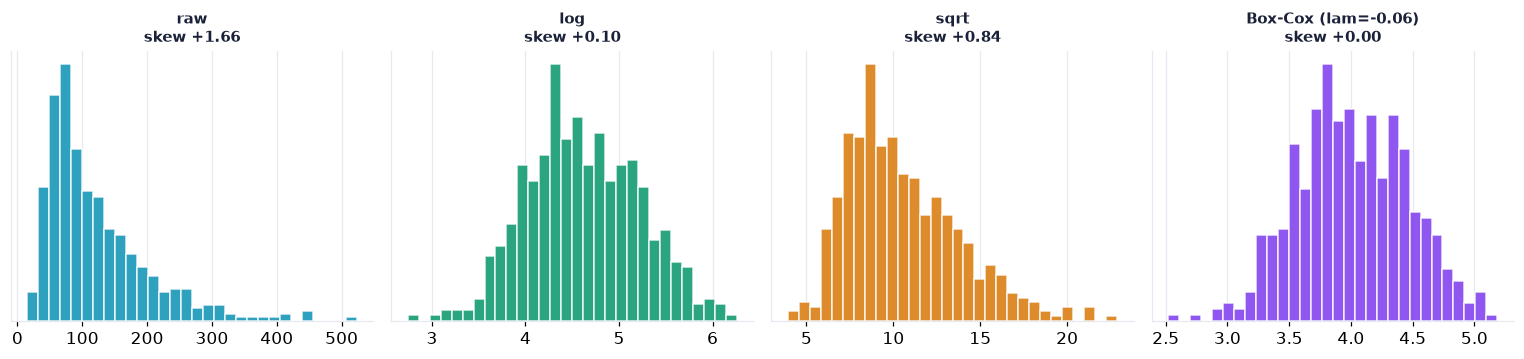

In [7]:
# --- Real-World beat: compare transforms by how far they cut the skew ---
from scipy import stats
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    api = pd.read_excel("../../data/ch22_response_times.xlsx", sheet_name="Data")
except FileNotFoundError: api = pd.read_excel(BASE+"ch22_response_times.xlsx", sheet_name="Data")
r = api.response_ms
bc, lam = stats.boxcox(r)
variants = {"raw": r, "log": np.log(r), "sqrt": np.sqrt(r), f"Box-Cox (lam={lam:.2f})": pd.Series(bc)}
for name, v in variants.items():
    print(f"{name:22s} skewness = {pd.Series(v).skew():+.2f}")
print("\nlog and Box-Cox pull the skew to about 0; the square root only helps partway.")
fig, ax = plt.subplots(1, 4, figsize=(14,3.4))
cols = [CYAN, GREEN, AMBER, PURPLE]
for a, (name, v), c in zip(ax, variants.items(), cols):
    a.hist(v, bins=30, color=c, alpha=0.85, edgecolor="white")
    a.set_title(f"{name}\nskew {pd.Series(v).skew():+.2f}", fontsize=10); a.set_yticks([])
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>A transform is <b>nonlinear</b>, so it reshapes the distribution (standardizing, Chapter 12, does not).</li>
<li><b>Log</b> pulls in a right skew and turns ratios into distances; it needs strictly positive data.</li>
<li>The <b>ladder of powers</b>: down (sqrt, log, 1/x) for right skew, up (x squared) for left skew.</li>
<li><b>Square root</b> stabilizes the variance of count (Poisson) data; <b>Box-Cox</b> auto-picks the best power.</li>
<li>Always <b>back-transform</b> to report; but exp(mean of logs) is the geometric mean, biased low, so report the median.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>